# 01 — Предобработка данных

Этот ноутбук готовит данные для всех моделей.

Важная идея:

- `TARGET_MODE = "raw"` — модели обучаются на обычной цене `Price`.
- `TARGET_MODE = "log"` — модели обучаются на `Price_log = log1p(Price)`, но настоящая цена `Price` сохраняется в рублях.

Все последующие ноутбуки моделей читают `target_column.json` и автоматически считают метрики **в рублях**, даже если обучение было на логарифме.

In [1]:
from pathlib import Path
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## 1. Настройки

Чтобы переключаться между обычной ценой и логарифмом, меняй только `TARGET_MODE`.

- `"raw"` — обучение на обычных ценах.
- `"log"` — обучение на логарифме цены.

In [2]:
TARGET_MODE = "raw"  # варианты: "raw" или "log"

DATA_PATTERN = "../data/processed/202*/moscow_202*.csv"
DATA_DIR = Path("../data/modeling")
REPORTS_DIR = Path("../reports")

DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_RAW = "Price"
TARGET_LOG = "Price_log"

FEATURES = [
    "Apartment type",
    "Metro station",
    "Minutes to metro",
    "Number of rooms",
    "Area",
    "Living area",
    "Kitchen area",
    "Floor",
    "Number of floors",
    "Renovation",
]

if TARGET_MODE not in {"raw", "log"}:
    raise ValueError("TARGET_MODE должен быть 'raw' или 'log'")

print("Режим таргета:", TARGET_MODE)

Режим таргета: raw


## 2. Загружаем CSV

In [3]:
files = sorted(glob.glob(DATA_PATTERN))

print("Найдено файлов:", len(files))
for file in files:
    print(file)

if not files:
    raise FileNotFoundError(f"Не найдено файлов по шаблону: {DATA_PATTERN}")

Найдено файлов: 4
../data/processed/2023/moscow_2023.csv
../data/processed/2024/moscow_2024.csv
../data/processed/2025/moscow_2025.csv
../data/processed/2026/moscow_2026.csv


In [4]:
dfs = []

for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = file
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Размер исходной таблицы:", df.shape)
df.head()

Размер исходной таблицы: (23508, 16)


,Price,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,source_file,Region,district,street,registration_quarter
0,108800000.0,Secondary,Чеховская,5.0,3.0,108.8,57.1,15.6,3.0,3.0,Without renovation,../data/processed/2023/moscow_2023.csv,NaN,NaN,NaN,NaN
1,53000000.0,Secondary,Арбатская,9.0,3.0,96.9,59.0,11.1,2.0,5.0,Without renovation,../data/processed/2023/moscow_2023.csv,NaN,NaN,NaN,NaN
2,44240000.0,Secondary,Фили,6.0,3.0,63.2,34.1,11.9,40.0,41.0,Designer,../data/processed/2023/moscow_2023.csv,NaN,NaN,NaN,NaN
3,105000000.0,Secondary,Белорусская,6.0,3.0,145.0,75.4,18.6,3.0,6.0,Designer,../data/processed/2023/moscow_2023.csv,NaN,NaN,NaN,NaN
4,47000000.0,Secondary,Белорусская,9.0,3.0,103.8,59.0,15.0,6.0,6.0,Without renovation,../data/processed/2023/moscow_2023.csv,NaN,NaN,NaN,NaN


## 3. Проверяем нужные колонки

In [5]:
required_columns = FEATURES + [TARGET_RAW]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Не найдены колонки: {missing_columns}")

df = df[required_columns + ["source_file"]].copy()

print("Размер исходной таблицы:", df.shape)
df.head()

Размер исходной таблицы: (23508, 12)


,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,Price,source_file
0,Secondary,Чеховская,5.0,3.0,108.8,57.1,15.6,3.0,3.0,Without renovation,108800000.0,../data/processed/2023/moscow_2023.csv
1,Secondary,Арбатская,9.0,3.0,96.9,59.0,11.1,2.0,5.0,Without renovation,53000000.0,../data/processed/2023/moscow_2023.csv
2,Secondary,Фили,6.0,3.0,63.2,34.1,11.9,40.0,41.0,Designer,44240000.0,../data/processed/2023/moscow_2023.csv
3,Secondary,Белорусская,6.0,3.0,145.0,75.4,18.6,3.0,6.0,Designer,105000000.0,../data/processed/2023/moscow_2023.csv
4,Secondary,Белорусская,9.0,3.0,103.8,59.0,15.0,6.0,6.0,Without renovation,47000000.0,../data/processed/2023/moscow_2023.csv


## 4. Очистка цены

In [6]:
counters = {'cnt1': 0, 'cnt2': 0, 'cnt3': 0, 'cnt4': 0}

def clean_price(value):
    counters['cnt1']+=1
    #if pd.isna(value):
    #    return np.nan

    counters['cnt2']+=1
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    counters['cnt3']+=1
    value = str(value)
    value = value.replace("₽", "")
    value = value.replace("руб.", "")
    value = value.replace("руб", "")
    value = value.replace(" ", "")
    value = value.replace(",", ".")

    cleaned = "".join(ch for ch in value if ch.isdigit() or ch == ".")

    if cleaned == "":
        return np.nan

    counters['cnt4']+=1
    return float(cleaned)

print(df[df[TARGET_RAW].isna()][TARGET_RAW])

df[TARGET_RAW] = df[TARGET_RAW].apply(clean_price)

print( counters['cnt1'], counters['cnt2'],counters['cnt3'],counters['cnt4'])

df[TARGET_RAW].describe()

Series([], Name: Price, dtype: float64)
23508 23508 0 0


count    2.350800e+04
mean     5.095367e+07
std      9.450304e+07
min      8.000000e+05
25%      1.105456e+07
50%      1.935000e+07
75%      4.770030e+07
max      3.737636e+09
Name: Price, dtype: float64

In [7]:
before = len(df)

df = df.dropna(subset=[TARGET_RAW]).copy()

after = len(df)

print("Было строк:", before)
print("Стало строк после удаления пустых Price:", after)
print("Удалено:", before - after)

Было строк: 23508
Стало строк после удаления пустых Price: 23508
Удалено: 0


## 5. Графики цены до удаления выбросов

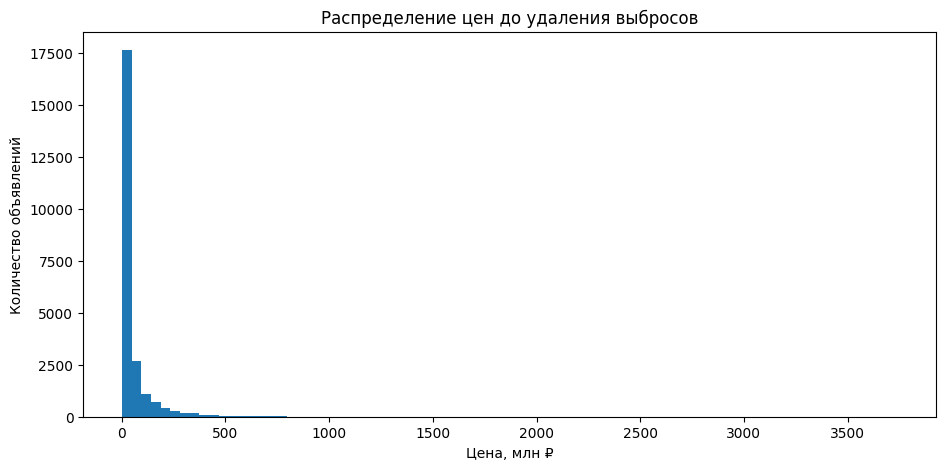

In [8]:
price_mln = df[TARGET_RAW] / 1_000_000

ax = price_mln.plot(
    kind="hist",
    bins=80,
    figsize=(11, 5),
    title="Распределение цен до удаления выбросов"
)

ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Количество объявлений")
plt.show()

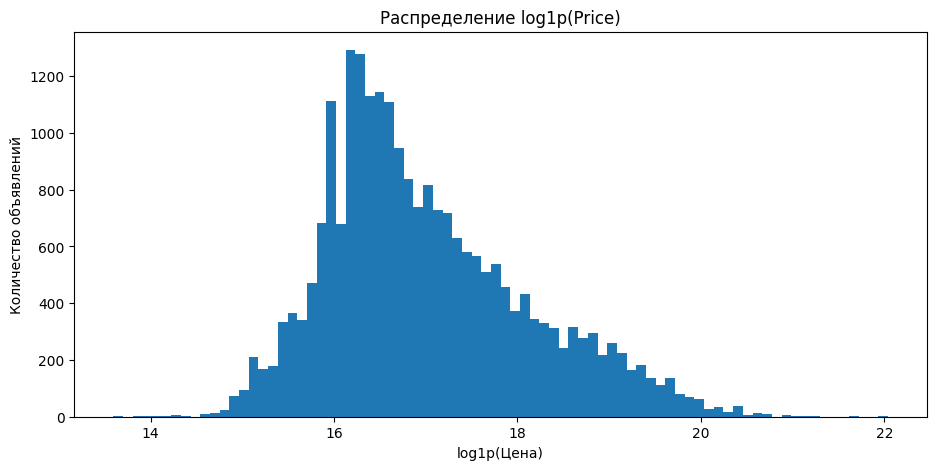

In [9]:
ax = np.log1p(df[TARGET_RAW]).plot(
    kind="hist",
    bins=80,
    figsize=(11, 5),
    title="Распределение log1p(Price)"
)

ax.set_xlabel("log1p(Цена)")
ax.set_ylabel("Количество объявлений")
plt.show()

## 6. Удаляем крайние 5% выбросов по цене

In [10]:
low_price = df[TARGET_RAW].quantile(0.05)
high_price = df[TARGET_RAW].quantile(0.95)

print("5% квантиль:", f"{low_price:,.0f}".replace(",", " "), "₽")
print("100% квантиль:", f"{high_price:,.0f}".replace(",", " "), "₽")

df_model = df[
    (df[TARGET_RAW] >= low_price) &
    (df[TARGET_RAW] <= high_price)
].copy()

print("Было строк:", len(df))
print("Стало строк:", len(df_model))

df_model[TARGET_RAW].describe()

5% квантиль: 5 492 019 ₽
100% квантиль: 205 649 293 ₽
Было строк: 23508
Стало строк: 21156


count    2.115600e+04
mean     3.613970e+07
std      4.005439e+07
min      5.499000e+06
25%      1.158150e+07
50%      1.935000e+07
75%      4.200000e+07
max      2.055700e+08
Name: Price, dtype: float64

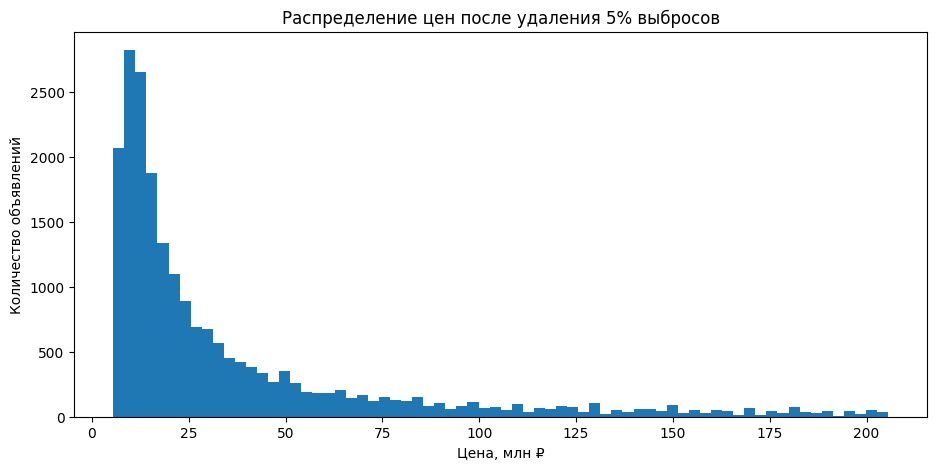

In [11]:
price_mln = df_model[TARGET_RAW] / 1_000_000

ax = price_mln.plot(
    kind="hist",
    bins=70,
    figsize=(11, 5),
    title="Распределение цен после удаления 5% выбросов"
)

ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Количество объявлений")
plt.show()

## 7. Создаём логарифмированный таргет, если нужен

In [12]:
# Price всегда остаётся настоящей ценой в рублях.
# Price_log создаётся отдельно и используется как target только в режиме TARGET_MODE='log'.

df_model[TARGET_LOG] = np.log1p(df_model[TARGET_RAW])

if TARGET_MODE == "raw":
    TARGET = TARGET_RAW
    TARGET_ORIGINAL = TARGET_RAW
    TARGET_TRANSFORM = "none"
    TRAINED_ON = "raw Price"
else:
    TARGET = TARGET_LOG
    TARGET_ORIGINAL = TARGET_RAW
    TARGET_TRANSFORM = "log1p"
    TRAINED_ON = "log1p(Price)"

print("Модель будет обучаться на:", TARGET)
print("Метрики будут считаться по:", TARGET_ORIGINAL)
print("Преобразование таргета:", TARGET_TRANSFORM)

df_model[[TARGET_RAW, TARGET_LOG]].head()

Модель будет обучаться на: Price
Метрики будут считаться по: Price
Преобразование таргета: none


,Price,Price_log
0,108800000.0,18.505022
1,53000000.0,17.785802
2,44240000.0,17.605140
3,105000000.0,18.469471
4,47000000.0,17.665658


## 8. Пропуски в признаках

In [13]:
missing_features = (
    df_model[FEATURES]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_share")
)

missing_features

,missing_share
Floor,0.013330
Number of floors,0.013330
Minutes to metro,0.001229
Metro station,0.001229
Apartment type,0.000000
Number of rooms,0.000000
Living area,0.000000
Area,0.000000
Kitchen area,0.000000
Renovation,0.000000


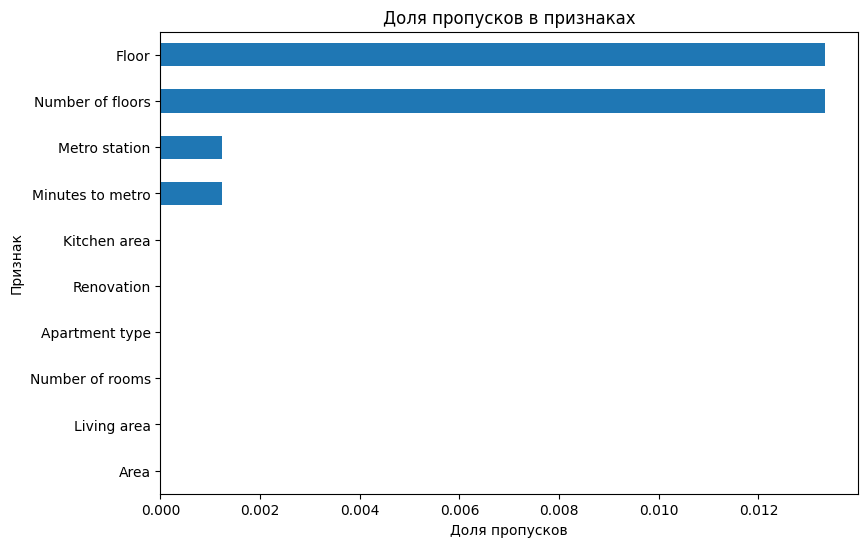

In [14]:
ax = missing_features.sort_values("missing_share").plot(
    kind="barh",
    figsize=(9, 6),
    title="Доля пропусков в признаках",
    legend=False
)

ax.set_xlabel("Доля пропусков")
ax.set_ylabel("Признак")
plt.show()

## 9. Train/test split

In [15]:
# В train/test сохраняем и Price, и Price_log.
# Так модель может обучаться на нужном TARGET, а метрики всегда можно считать в рублях по Price.

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (16924, 13)
Test: (4232, 13)


## 10. Сохраняем данные и метаинформацию

In [16]:
train_path = DATA_DIR / "moscow_train.csv"
test_path = DATA_DIR / "moscow_test.csv"
full_path = DATA_DIR / "moscow_modeling_full.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)
df_model.to_csv(full_path, index=False)

with open(DATA_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(FEATURES, f, ensure_ascii=False, indent=2)

target_info = {
    "target": TARGET,
    "target_original": TARGET_ORIGINAL,
    "target_transform": TARGET_TRANSFORM,
    "trained_on": TRAINED_ON,
}

with open(DATA_DIR / "target_column.json", "w", encoding="utf-8") as f:
    json.dump(target_info, f, ensure_ascii=False, indent=2)

with open(DATA_DIR / "preprocessing_mode.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "target_mode": TARGET_MODE,
            "low_price_quantile": 0.01,
            "high_price_quantile": 0.99,
            "low_price_value": float(low_price),
            "high_price_value": float(high_price),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Сохранено:")
print(train_path)
print(test_path)
print(full_path)
print(DATA_DIR / "feature_columns.json")
print(DATA_DIR / "target_column.json")
print(DATA_DIR / "preprocessing_mode.json")
print()
print("target_info:")
target_info

Сохранено:
../data/modeling/moscow_train.csv
../data/modeling/moscow_test.csv
../data/modeling/moscow_modeling_full.csv
../data/modeling/feature_columns.json
../data/modeling/target_column.json
../data/modeling/preprocessing_mode.json

target_info:


{'target': 'Price',
 'target_original': 'Price',
 'target_transform': 'none',
 'trained_on': 'raw Price'}